<a href="https://colab.research.google.com/github/AdeelAsghar11/deep-learning-playground/blob/main/Genetic_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import heapq

goal = ((1, 2, 3),
        (4, 5, 6),
        (7, 8, 0))

# Manhattan distance heuristic
def manhattan(state):
    distance = 0
    for i in range(3):
        for j in range(3):
            value = state[i][j]
            if value != 0:
                goal_x = (value - 1) // 3
                goal_y = (value - 1) % 3
                distance += abs(i - goal_x) + abs(j - goal_y)
    return distance

# Find blank position
def find_zero(state):
    for i in range(3):
        for j in range(3):
            if state[i][j] == 0:
                return i, j

# Generate neighbors
def neighbors(state):
    x, y = find_zero(state)
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    result = []
    for dx, dy in moves:
        nx, ny = x + dx, y + dy
        if 0 <= nx < 3 and 0 <= ny < 3:
            new_state = [list(row) for row in state]
            new_state[x][y], new_state[nx][ny] = new_state[nx][ny], new_state[x][y]
            result.append(tuple(tuple(row) for row in new_state))
    return result

# A* algorithm
def astar(start):
    open_list = []
    heapq.heappush(open_list, (0, start))
    g = {start: 0}
    parent = {start: None}

    while open_list:
        current = heapq.heappop(open_list)[1] # Note: Added [1] to extract state from tuple

        if current == goal:
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1]

        for next_state in neighbors(current):
            tentative_g = g[current] + 1
            if next_state not in g or tentative_g < g[next_state]:
                g[next_state] = tentative_g
                f = tentative_g + manhattan(next_state)
                heapq.heappush(open_list, (f, next_state))
                parent[next_state] = current
    return None

start = ((1, 2, 3),
         (4, 0, 6),
         (7, 5, 8))

solution = astar(start)
for step in solution:
    print(step)
    print()

((1, 2, 3), (4, 0, 6), (7, 5, 8))

((1, 2, 3), (4, 5, 6), (7, 0, 8))

((1, 2, 3), (4, 5, 6), (7, 8, 0))



population [ 1.12153619 -0.94829798  0.7815482   1.15310088  0.51066464  0.389717
  1.54268094 -0.21097652 -0.92829003 -0.63484062 -0.37736408  0.7020367
  0.03721623  0.99291317  0.94635627 -0.87294139  0.19585506  1.16853132
  1.25544725  0.87889664 -0.99355957  0.02732266  0.02316673  1.00657791
  1.90799102  0.48094875  0.27422378  1.7075429  -0.18111786  1.00978214]
Selection [-0.37736408  0.27422378  1.00978214  0.389717    0.27422378  0.27422378
  0.19585506 -0.21097652  0.51066464 -0.18111786 -0.87294139 -0.21097652
  1.00978214 -0.18111786 -0.63484062 -0.99355957  0.87889664  0.02316673
  0.02316673 -0.21097652  0.7020367  -0.87294139 -0.21097652 -0.21097652
 -0.63484062 -0.18111786  0.51066464  1.00657791  0.51066464 -0.99355957]
Parents:parent1, parent2 -0.3773640762143414 0.2742237825926872
child1, child2 CrossOver -0.35941064967791 0.25627035605625575
Parents:parent1, parent2 1.009782135511876 0.3897169982196873
child1, child2 CrossOver 1.009782135511876 0.3897169982196873

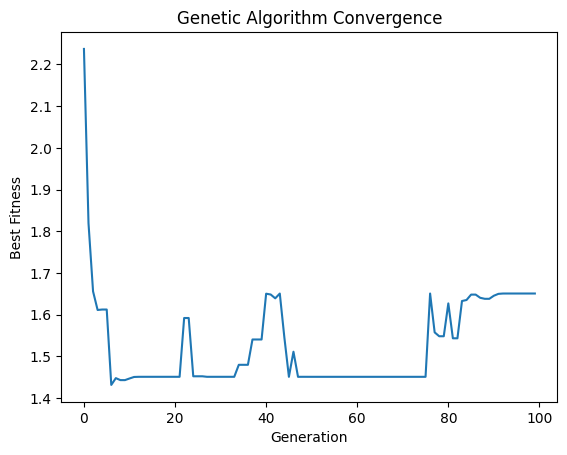

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Objective function (maximize)
def fitness(x):
    return x * np.sin(10 * np.pi * x) + 1

# Genetic Algorithm
def genetic_algorithm(pop_size=30, generations=100, crossover_rate=0.8, mutation_rate=0.1, bounds=(-1, 2)):
    # Initialize population
    population = np.random.uniform(bounds[0], bounds[1], pop_size)
    best_history = []
    print("population", population)

    for generation in range(generations):
        # Evaluate fitness
        fitness_values = np.array([fitness(ind) for ind in population])

        # Store best value
        best_history.append(np.max(fitness_values))

        # Selection (Tournament Selection)
        selected = []
        for _ in range(pop_size):
            i, j = random.sample(range(pop_size), 2)
            winner = population[i] if fitness_values[i] > fitness_values[j] else population[j]
            selected.append(winner)
        selected = np.array(selected)
        print("Selection", selected)

        # Crossover
        next_population = []
        for i in range(0, pop_size, 2):
            parent1 = selected[i]
            parent2 = selected[i+1]
            print("Parents:parent1, parent2", parent1, parent2)

            if random.random() < crossover_rate:
                alpha = random.random()
                child1 = alpha * parent1 + (1 - alpha) * parent2
                child2 = alpha * parent2 + (1 - alpha) * parent1
            else:
                child1, child2 = parent1, parent2

            print("child1, child2 CrossOver", child1, child2)
            next_population.extend([child1, child2])

        population = np.array(next_population)
        print("CrossOver Population", population)

        # Mutation
        for i in range(pop_size):
            if random.random() < mutation_rate:
                population[i] += np.random.normal(0, 0.1)

        # Keep within bounds
        population = np.clip(population, bounds[0], bounds[1])
        print("Mutation: Population to clip within bounds", population)

    # Final best solution
    fitness_values = np.array([fitness(ind) for ind in population])
    print("Fitness Values as best solution", fitness_values)
    best_index = np.argmax(fitness_values)

    return population[best_index], fitness_values[best_index], best_history

# Run Genetic Algorithm
best_x, best_fitness, history = genetic_algorithm()
print("Best Solution x:", best_x)
print("Maximum Fitness f(x):", best_fitness)

# Plot convergence
plt.plot(history)
plt.title("Genetic Algorithm Convergence")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.show()

In [ ]:
import random
import numpy as np

# Example population (real-valued)
population = np.array([1.2, -0.5, 2.3, 0.7, 1.8])

# Fitness function (maximize)
def fitness(x):
    return x**2 # simple example

# Tournament selection function
def tournament_selection(population, fitness_func, k=3):
    selected = []
    pop_size = len(population)

    for _ in range(pop_size):
        # Randomly select k individuals
        tournament_indices = random.sample(range(pop_size), k)
        tournament = population[tournament_indices]

        # Evaluate fitness
        tournament_fitness = [fitness_func(ind) for ind in tournament]

        # Select winner
        winner_index = tournament_indices[tournament_fitness.index(max(tournament_fitness))]
        selected.append(population[winner_index])

    return np.array(selected)

# Perform tournament selection
new_population = tournament_selection(population, fitness, k=2)

print("Original Population:", population)
print("New Population After Tournament Selection:", new_population)

Original Population: [ 1.2 -0.5  2.3  0.7  1.8]
New Population After Tournament Selection: [1.2 1.8 2.3 2.3 2.3]


In [ ]:
import numpy as np
import random

# Fitness Function (maximize)
def fitness(x):
    return x**2 # simple example

# Probabilistic Tournament Selection
def probabilistic_tournament(population, fitness_func, k=3, p=0.7):
    pop_size = len(population)
    new_population = []

    for _ in range(pop_size):
        # Randomly select k individuals
        indices = random.sample(range(pop_size), k)
        tournament = [population[i] for i in indices]

        # Sort tournament by fitness descending
        sorted_tournament = sorted(tournament, key=lambda x: fitness_func(x), reverse=True)

        # Compute geometric selection probabilities
        probs = [p * (1 - p)**i for i in range(k)]
        total = sum(probs)
        probs = [prob / total for prob in probs] # normalize

        # Select one individual based on probabilities
        r = random.random()
        cumulative = 0
        for i in range(k):
            cumulative += probs[i]
            if r <= cumulative:
                winner = sorted_tournament[i]
                break

        new_population.append(winner)

    return np.array(new_population)

# Demo: Small Population Example
def demo_probabilistic_tournament():
    population = np.array([1, 2, 3, -4, 2]) # small dataset
    generations = 5
    tournament_size = 3
    p_best = 0.7

    print("Initial Population:", population)
    for g in range(generations):
        population = probabilistic_tournament(
            population, fitness, k=tournament_size, p=p_best
        )
        print(f"Generation {g+1}:", population)

    # Show best individual
    best = max(population, key=fitness)
    print("Best Individual:", best)
    print("Best Fitness:", fitness(best))

# Run Demo
if __name__ == "__main__":
    demo_probabilistic_tournament()

Initial Population: [ 1  2  3 -4  2]
Generation 1: [ 1 -4  3  3 -4]
Generation 2: [-4  3 -4 -4 -4]
Generation 3: [-4 -4 -4 -4 -4]
Generation 4: [-4 -4 -4 -4 -4]
Generation 5: [-4 -4 -4 -4 -4]
Best Individual: -4
Best Fitness: 16


In [ ]:
import numpy as np
import random

# Fitness Function (maximize)
def fitness(x):
    return x**2 # maximize x^2

# Probabilistic Tournament Selection
def probabilistic_tournament(population, fitness_func, k=3, p=0.7):
    pop_size = len(population)
    new_population = []

    for _ in range(pop_size):
        # Randomly select k individuals
        indices = random.sample(range(pop_size), k)
        tournament = [population[i] for i in indices]

        # Sort tournament by fitness descending
        sorted_tournament = sorted(tournament, key=lambda x: fitness_func(x), reverse=True)

        # Probabilities
        probs = [p * (1 - p)**i for i in range(k)]
        total = sum(probs)
        probs = [prob / total for prob in probs]

        # Probabilistic selection
        r = random.random()
        cumulative = 0
        for i in range(k):
            cumulative += probs[i]
            if r <= cumulative:
                winner = sorted_tournament[i]
                break

        new_population.append(winner)

    return np.array(new_population)

# Single-point Crossover
def crossover(parent1, parent2, crossover_rate=0.8):
    if random.random() < crossover_rate:
        alpha = random.random() # blend real-valued crossover
        child1 = alpha * parent1 + (1 - alpha) * parent2
        child2 = alpha * parent2 + (1 - alpha) * parent1
        return child1, child2
    else:
        return parent1, parent2

# Mutation
def mutate(individual, mutation_rate=0.1, mutation_range=1.0):
    if random.random() < mutation_rate:
        individual += random.uniform(-mutation_range, mutation_range)
        # keep individual within bounds [-5,5]
        individual = max(min(individual, 5), -5)

    return individual

# Full Genetic Algorithm
def genetic_algorithm(pop_size=6, generations=10, tournament_k=3, p_tournament=0.7, crossover_rate=0.8, mutation_rate=0.1):
    # Initialize population randomly in [-5,5]
    population = np.random.uniform(-5, 5, pop_size)
    print("Initial Population:", population)

    for gen in range(generations):
        # Selection
        mating_pool = probabilistic_tournament(population, fitness, k=tournament_k, p=p_tournament)

        # Crossover
        next_gen = []
        for i in range(0, pop_size, 2):
            parent1 = mating_pool[i]
            parent2 = mating_pool[i+1] if i+1 < pop_size else mating_pool[0]

            child1, child2 = crossover(parent1, parent2, crossover_rate)
            next_gen.extend([child1, child2])

        population = np.array(next_gen[:pop_size])

        # Mutation
        population = np.array([mutate(ind, mutation_rate) for ind in population])

        # Print generation info
        best_ind = max(population, key=fitness)
        print(f"Generation {gen+1}: Population={np.round(population, 2)}, Best={best_ind}, Fitness={fitness(best_ind)}")

    # Final best solution
    best_individual = max(population, key=fitness)
    print("\nFinal Best Individual:", best_individual)
    print("Final Best Fitness:", fitness(best_individual))

# Run GA
if __name__ == "__main__":
    genetic_algorithm(
        pop_size=6,
        generations=10,
        tournament_k=3,
        p_tournament=0.7,
        crossover_rate=0.8,
        mutation_rate=0.2
    )

Initial Population: [-0.18253762 -3.87267953  3.05710434  0.57646953  1.92310477  1.49572945]
Generation 1: Population=[ 2.37  2.03 -3.87 -3.87  1.32  1.71], Best=-3.8726795259113755, Fitness=14.997646710413157
Generation 2: Population=[-3.87 -3.87 -3.87 -3.87 -3.87 -3.87], Best=-3.8726795259113755, Fitness=14.997646710413157
Generation 3: Population=[-3.87 -3.87 -3.87 -3.87 -3.87 -3.87], Best=-3.8726795259113755, Fitness=14.997646710413157
Generation 4: Population=[-3.7  -3.87 -3.87 -3.04 -3.87 -3.87], Best=-3.8726795259113755, Fitness=14.997646710413157
Generation 5: Population=[-3.87 -3.87 -3.87 -3.35 -3.87 -4.27], Best=-4.267552494128321, Fitness=18.21200429014085
Generation 6: Population=[-4.27 -3.92 -4.1  -4.04 -3.27 -3.87], Best=-4.2667824942503465, Fitness=18.20543285324121
Generation 7: Population=[-3.87 -3.16 -3.29 -4.1  -3.31 -4.27], Best=-4.2667824942503465, Fitness=18.20543285324121
Generation 8: Population=[-3.6  -3.81 -4.3  -3.88 -4.27 -4.48], Best=-4.4817840739067245, F